<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 10 - Sequential Perception and Review</h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h3>Master in Cognitive Science</h3>
            <h4>École Normale Supérieure - PSL</h4>
            <p> Valentin Wyart - Lecturer<br>
                Amric Trudel - Practical Sessions (TD)<br>
                <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

## Objective
In this TD, we will work on a new type of task: a sequential perception task. You will implement two different models and run all the steps that we have seen so far:
- Understand the task
- Implement two models
- Simulate behavior
- Parameter recovery
- Model recovery
- Fit models to behavioral data
- Model selection
    - Fixed effect
    - Random effect

In [1]:
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from tqdm import trange, tqdm

from TD_10.tests import test_integration_model_update, test_integration_model_policy, test_extremum_model_update, test_extremum_model_policy
from models import Model, Parameter
from sequential_perception_task import SequentialPerceptionTask, dist_orange, dist_blue

In [2]:
%reload_ext autoreload
%autoreload 2

## The Task

We will work on a sequential perception task where the subject must choose between two bags (orange and blue). At every block, the subject sees a sequence of stimuli (colored beads) that are sampled from one of the bags. The subject must choose the bag that is most likely to have produced the sequence of stimuli. The figure below illustrates the distribution of color values for each bag.
<img src="images/task_stimuli_distributions.png" alt="Task" style="width: 500px;"/>

The stimuli that are shown are circles whose color is given by a number between -1 and 1:
   - -1 is completely blue
   - 0 is grey
   - 1 is completely orange

Both bags contain beads of all types of colors, but the orange bag contains more orange beads.

The `dist_orange` and `dist_blue` distributions are imported in this notebook and represent the color distributions of each bag.
They are implemented to behave as a `scipy.stats` distributions. Two useful methods for these distributions are:
- `dist_*.pdf(x)`: Probability density function, returns the likelihood that a stimulus of color `x` was taken from that distribution.
- `dist_*.rvs(size)`: Random variates, returns a sample of `size` values draw from the distribution.

📝Plot the probability density functions of those two distributions on the same graph. You should obtain something like a merged version of the figure above.

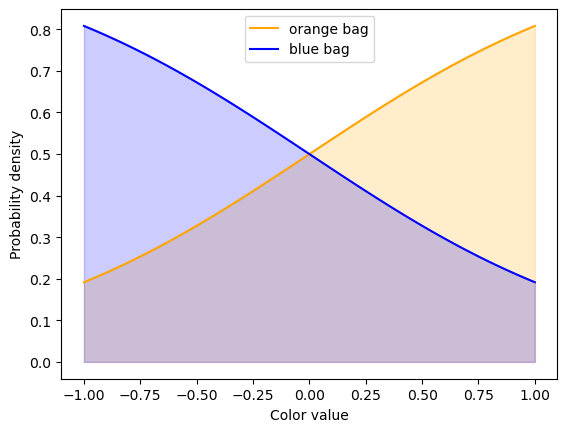

In [3]:
# Solution
x = np.linspace(-1, 1, 100)
p_orange = dist_orange.pdf(x)
p_blue = dist_blue.pdf(x)

plt.plot(x, p_orange, color='orange', label='orange bag')
plt.plot(x, p_blue, color='blue', label='blue bag')
plt.fill_between(x, p_orange, color='orange', alpha=0.2)
plt.fill_between(x, p_blue, color='blue', alpha=0.2)
plt.xlabel('Color value')
plt.ylabel('Probability density')
plt.legend()
plt.show()

The `SequentialPerceptionTask` class is already provided to you and imported in this notebook. It behaves like the `BanditTask` class that we used in previous TDs, except that we have to adapt the notions of *trial* and *block*. In this experiment, we will consider that a **trial** corresponds to the presentation of a new stimulus, and a **block** corresponds to the sequence of stimuli presented to the subject before they choose a bag.

In other words:
- `n_trials` represent the number of stimuli shown in each sequence
- The subject must choose a bag after the n trials
- `n_blocks` is the number of sequences (decisions) taken.

⚠️This task is different from the Bandit Task. Now we have only one subject response per block, and there are **no rewards**.

📝Instantiate a demo task with the `SequentialPerceptionTask` class with **8 trials** and **8 blocks.** Use a **seed of 42** to make the task reproducible.

We will call the `plot()` method to visualize the task. You should see a plot with 8 rows corresponding to the blocks of stimuli, and a final circle corresponding to the actual bag from which the sequence was drawn (ground truth).

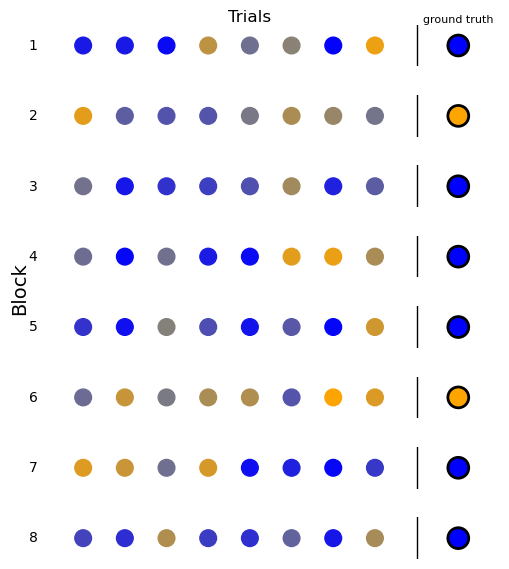

In [4]:
# Solution
demo_task = SequentialPerceptionTask(n_trials=8, n_blocks=8, seed=42)
demo_task.plot()

## The Models
We will propose two models to explain the behavior of the subject in this task:
1. An **integration model** that integrates the evidence over time
2. An **extremum detection model** that only remembers the most salient stimulus

Before you start this sections, pay careful attention to the following points:

**The `Model` base class**

The classes that implement those models both inherit from the `Model` base class. The `Model` class is written in the `models.py` file and provides some useful methods that we have dealt with before and that you can use now without having to implement them yourself. These methods include:
- `simulate()`: Simulates the task with the model and returns the choices.
- `fit()`: Fits the model to the data and returns the fitted model.
- `log_likelihood()`: Computes the log likelihood of the model given the behavioral data.
- `plot()`: Plots the model's behavior.

**The Parameters**

Another new feature of this TD is that now the model classes have a `parameters` attribute that defines the parameters of the model. This attribute is a list of `Parameter` objects (also defined in the `models.py` file). Each `Parameter` object has the following attributes, which will be useful for the model fitting with BADS:
- `name`: The name of the parameter.
- `initial_value`: The initial value of the parameter.
- `distribution`: The distribution of the parameter. This is a `scipy.stats` distribution object that defines the distribution of the parameter.
- `bounds`: The bounds of the parameter. This is a tuple that defines the minimum and maximum values of the parameter.
- `plausible_bounds`: The plausible bounds of the parameter. This is a tuple that defines the minimum and maximum values of the parameter that are plausible for the model.

**Vectorized implementation**

In order to facilitate the computing of the log likelihood, we will used a vectorized processing of the blocks of trials. In other words, we process all blocks of the task simultaneously. This means that numpy array must be defined in two dimensions, where:
- The first dimension (0) corresponds to the number of blocks
- The second dimension (1) corresponds to the number of trials in each block

So:
- **stimuli** will be a 2D numpy array of shape (n_blocks, n_trials)
- **stimulus** (one trial) will be a 2D numpy array of shape (n_blocks, 1)
- **probability of choice** will be a 2D numpy array of shape (n_blocks, 1)
- **evidence** will be a 2D numpy array of shape (n_blocks, 1)

Handling vectorized operations can be very tricky when you are not used to it, so don't hesitate to ask for help to get started.

### Model 1: Integration model
The **integration model** is a model that integrates the evidence over time. At the end of the block, the model uses a softmax policy to choose the bag based on the accumulated evidence.

The `IntegrationModel` class implements this model. It has two parameters:
- `leak`: The leak parameter that controls how much the evidence is forgotten over time. A value of 0 means no leak (the model remembers everything), and a value of 1 means complete leak (the model forgets everything).
- `temperature`: The temperature parameter that controls the stochasticity of the model. A value of 0 means no stochasticity (the model always chooses the bag with the highest evidence), and a value of 1 means high stochasticity (it is the same as ususal).

Instructions on how to fill this class are given below the declaration.

In [5]:
# Solution
class IntegrationModel(Model):
    parameters = [
        Parameter(
            name='leak',
            initial_value=0.1,
            distribution=scipy.stats.uniform(0, 1),
            bounds=(0, 1),
            plausible_bounds=(0.05, 0.8)
        ),
        Parameter(
            name='temperature',
            initial_value=0.1,
            distribution=scipy.stats.expon(scale=0.1),
            bounds=(1e-6, 1),
            plausible_bounds=(0.01, 0.5)
        )
    ]

    def __init__(self, leak: float, temperature: float):
        self.leak: float = leak
        self.temperature: float = temperature
        self.n_blocks: Optional[int] = None
        self.evidence: Optional[np.ndarray[float]] = None

    def update(self, stimulus):
        # Update the evidence with the leak
        p_orange = dist_orange.pdf(stimulus)
        p_blue = dist_blue.pdf(stimulus)
        log_odds_ratio = np.log(p_orange) - np.log(p_blue)
        self.evidence = self.evidence * (1 - self.leak) + log_odds_ratio

    def policy(self):
        # Softmax policy to compute probability of playing action 1
        np.seterr(over='ignore')
        prob_choose_orange = 1 / (1 + np.exp(-self.evidence / self.temperature))
        np.seterr(over='warn')
        return prob_choose_orange

    def reset(self, n_blocks: int):
        self.n_blocks = n_blocks
        self.evidence = np.zeros((n_blocks, 1))

    def __repr__(self):
        return f"IntegrationModel(lk={self.leak: .2f}, t={self.temperature: .2f})"

#### 1) Parameter specifications
📝Fill the parameter specifications with what seems the most reasonable for you.

You can run the `plot_param_specs()` method to visualize the parameter space that you created (run the cell below)

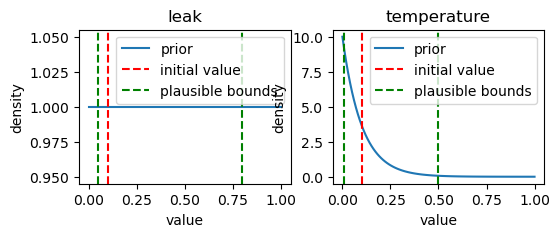

In [6]:
IntegrationModel(0, 0).plot_param_specs()

#### 2) Updating evidence
The evidence starts at 0 and is updated at every trial. When it gets positive, the model tilts towards the orange bag, and when it gets negative, it tilts towards the blue bag.

The evidence is calculated as th **log odds ratio** of the two distributions:
$$
\text{evidence} = \log \left( \frac{p_{\text{orange}}}{p_{\text{blue}}} \right)
$$
Where:
- $p_{\text{orange}}$ is the probability density function of the orange bag for the current stimulus
- $p_{\text{blue}}$ is the probability density function of the blue bag for the current stimulus
- $\frac{p_{\text{orange}}}{p_{\text{blue}}}$ is the odds ratio of the two distributions

The evidence is accumulated in an additive manner over trials. At every update, there is also partial forgetting of the evidence accumulated so far. This is mediated by a **leak** parameter that determines how much past evidence shrinks before we add the new one.

📝Implement the `update()` method to update the evidence with the log odds ratio of the two distributions. The evidence should be updated with the leak parameter.

In [7]:
test_integration_model_update(IntegrationModel)

OK 👌


#### 3) Policy
The model uses a softmax policy to choose the bag based on the accumulated evidence. The probability of choosing the orange bag is given by:
$$
P(\text{orange}) = \frac{1}{1 + \exp(-\frac{\text{evidence}}{\text{temperature}})}
$$

📝Implement the `policy()` method to compute the probability of choosing the orange bag using the softmax policy. The temperature parameter controls the stochasticity of the model.

In [8]:
test_integration_model_policy(IntegrationModel)

OK 👌


### Simulate the Integration model
Now that you have implemented the `IntegrationModel`, you can simulate the task with it. Let's start with the optimal model, which is the one that has no leak and no stochasticity.

📝Instantiate an optimal model and call the simulate method (you pass it the `demo_task` object and set `plot=True`).
See how the evidence is updated with each stimulus.

/var/folders/77/6qv_d5y10z56r3z236lrjs8w0000gn/T/ipykernel_4721/1928819616.py:36: RuntimeWarning: divide by zero encountered in divide
  prob_choose_orange = 1 / (1 + np.exp(-self.evidence / self.temperature))


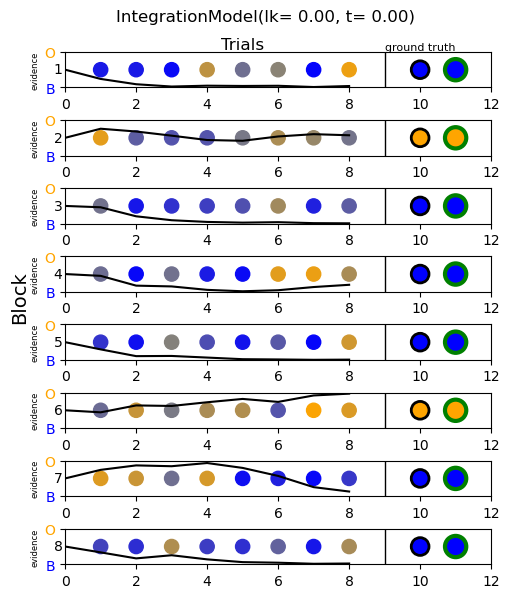

In [9]:
# Solution
optimal_integration_model = IntegrationModel(0, 0)
_ = optimal_integration_model.simulate(demo_task, plot=True)

📝Implement another `IntegrationModel` with different parameters and see if the evidence is updated differently and if the the responses are different. Try to understand the effect of each parameter.

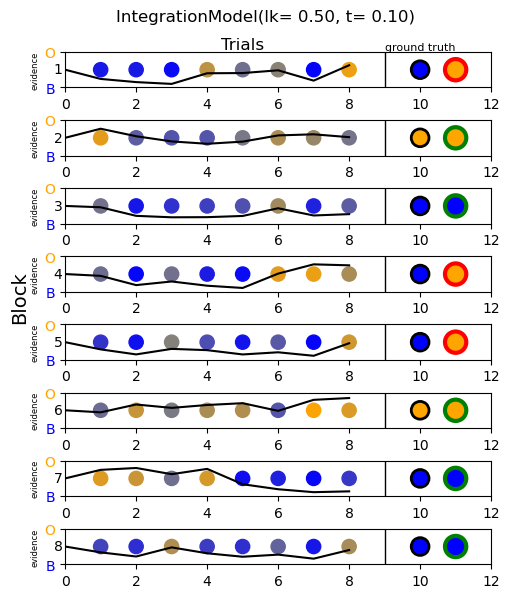

In [10]:
integration_model = IntegrationModel(0.5, 0.1)
_ = integration_model.simulate(demo_task, plot=True)

### Model 2: Extremum detection model
For comparison, let's make a simpler (and a bit more stupid) model: the **extremum detection model**. This model only remembers the most salient stimulus (the maximum or minimum value), and reports the bag that corresponds to its color. To spike things up a bit, we will add a stochasticity parameter to the model, so it will choose the opposite bag with a probability of `epsilon` (the epsilon-greedy policy).

The salience of a stimulus is just its absolute value (how far it is from 0).

In other words:
- If most salient stimulus > 0 (looks orange):
    - Choose orange with probability 1 - epsilon
    - Choose blue with probability epsilon
- If most salient stimuls < 0 (looks blue):
    - Choose blue with probability 1 - epsilon
    - Choose orange with probability epsilon


In [11]:
# Solution
class ExtremumDetectionModel(Model):
    parameters = [
        Parameter(
            name='epsilon',
            initial_value=0.1,
            distribution=scipy.stats.uniform(0, 1),
            bounds=(0, 1),
            plausible_bounds=(0.1, 0.4)
        )
    ]
    def __init__(self, epsilon: float):
        self.epsilon: float = epsilon
        self.n_blocks: Optional[int] = None
        self.evidence: Optional[np.ndarray[float]] = None

    def update(self, stimulus):
        update_condition = np.absolute(stimulus) > np.absolute(self.evidence)
        self.evidence = np.where(update_condition, stimulus, self.evidence)

    def policy(self):
        greedy_decision = (self.evidence > 0).astype(int)
        p_orange = greedy_decision * (1 - self.epsilon) + (1 - greedy_decision) * self.epsilon
        return p_orange.astype(float)

    def reset(self, n_blocks: int):
        self.n_blocks = n_blocks
        self.evidence = np.zeros((n_blocks, 1))

    def __repr__(self):
        return f'ExtremumDetectionModel(epsilon={self.epsilon: .2f})'

#### 1) Parameter specifications
📝 Fill the parameter specifications with what seems the most reasonable for you.

You can run the `plot_param_specs()` method to visualize the parameter space that you created (run the cell below)


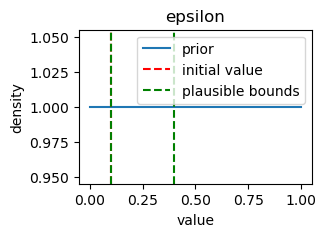

In [12]:
ExtremumDetectionModel(0).plot_param_specs()

#### 2) Updating evidence
In this model, the evidence will be stored as the value of the most salient stimulus.

At every trial, if the new stimulus is more salient (i.e. has a higher absolute value) than the current evidence, we update the evidence with the new stimulus.

📝 Implement the `update()` method to update the evidence with the most salient stimulus.

In [13]:
test_extremum_model_update(ExtremumDetectionModel)

OK 👌


#### 3) Policy
The model uses an epsilon-greedy policy to choose the bag based on the most salient stimulus. The probability of choosing the orange bag is given by:
$$
P(\text{orange}) = \begin{cases}
1 - \epsilon & \text{if evidence} > 0 \\
\epsilon & \text{if evidence} < 0
\end{cases}
$$
📝Implement the `policy()` method to compute the probability of choosing the orange bag using the epsilon-greedy policy. The epsilon parameter controls the stochasticity of the model.


In [14]:
test_extremum_model_policy(ExtremumDetectionModel)

OK 👌


### Simulate the Extremum detection model
Now that you have implemented the `ExtremumDetectionModel`, you can simulate the task with it. Let's start with the optimal model, which is the one that has no stochasticity.

📝Implement an optimal `ExtremumDetectionModel` and simulate it with the `demo_task` object.

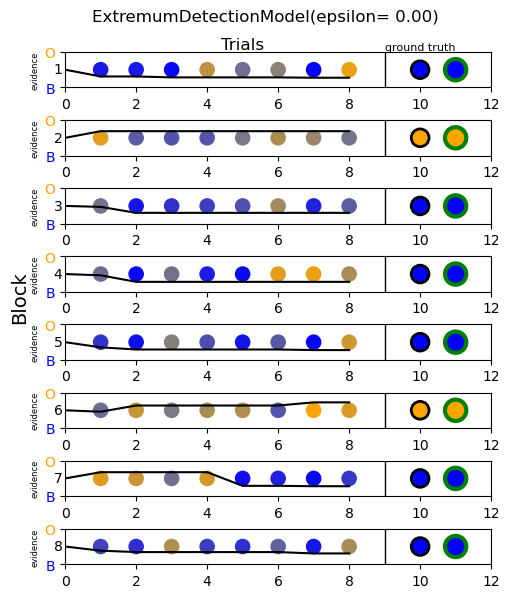

In [15]:
# Solution
optimal_extremum_model = ExtremumDetectionModel(0)
_ = optimal_extremum_model.simulate(demo_task, plot=True)

📝Implement another `ExtremumDetectionModel` with a different `epsilon` and see the effect on the evidence and the responses.

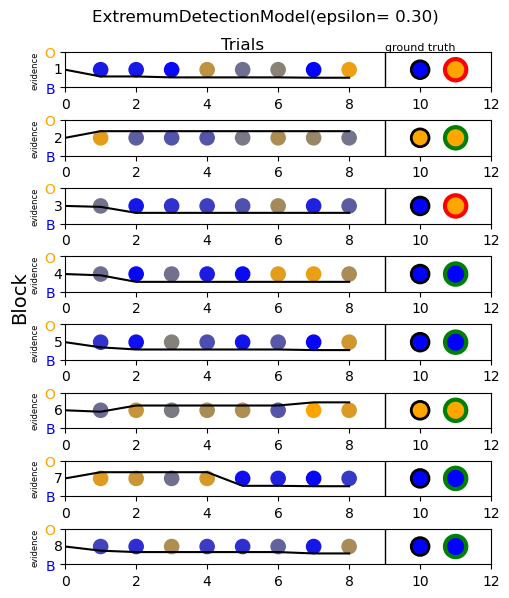

In [16]:
# Solution
extremum_model = ExtremumDetectionModel(0.3)
_ = extremum_model.simulate(demo_task, plot=True)

## Parameter recovery
### Write the functions
> Note: To debug your functions, you can run it on Model 1 with n_samplings=2.

Complete the `perform_parameter_recovery` function to perform parameter recovery for a model given model.
> Fill the `...` with the appropriate code.

In [17]:
# Solution
def perform_parameter_recovery(task, ModelClass, n_samplings):
    results = []
    for i in trange(n_samplings):
        # Sample parameters and instantiate original model
        ## CAREFUL! This part has changed :)
        original_params = {
            parameter.name: parameter.distribution.rvs()
            for parameter in ModelClass.parameters
        }
        original_model = ModelClass(**original_params)

        # Simulate task with the original model
        choices = original_model.simulate(task)

        # Fit the model to the simulated data
        recovered_model = ModelClass.fit(task, choices, verbose=False)

        recovered_params = {
            f"recovered_{parameter.name}": getattr(recovered_model, parameter.name)
            for parameter in ModelClass.parameters
        }

        results.append(pd.Series({**original_params, **recovered_params}))
    return pd.concat(results, axis=1).transpose()

## Test
# We run the function with the demo task to test it
perform_parameter_recovery(demo_task, IntegrationModel, 2)
perform_parameter_recovery(demo_task, ExtremumDetectionModel, 2)
print("👌The code runs")

  0%|          | 0/2 [00:00<?, ?it/s]/Users/amrictrudel/anaconda3/envs/ccm/lib/python3.11/site-packages/pybads/init_functions/init_sobol.py:39: RuntimeWarning: invalid value encountered in cast
  str_seed = u0[0 : np.minimum(11, len(u0))].astype(np.uint64)
100%|██████████| 2/2 [00:00<00:00,  7.71it/s]

👌The code runs


## Define the task to study

In [18]:
task = SequentialPerceptionTask(n_trials=8, n_blocks=200, seed=42)

## Parameter Recovery
### Parameter recovery for Model 1 (Integration Model)


📝Perform parameter recovery for the `IntegrationModel` with 30 samplings and store the result in `param_recov_integration`.

In [19]:
# Solution
param_recov_integration = perform_parameter_recovery(task, IntegrationModel, 30)
param_recov_integration.head()

100%|██████████| 30/30 [00:13<00:00,  2.29it/s]


,leak,temperature,recovered_leak,recovered_temperature
0,0.965822,0.056651,1.000000,0.036305
1,0.511307,0.190765,0.536130,0.126272
2,0.212224,0.062982,0.224389,0.057860
3,0.204632,0.064200,0.211559,0.000044
4,0.795580,0.025568,0.794719,0.015395


The function that plots the confusion matrix for the parameter recovery results is provided to you 🎁

In [20]:
def plot_param_recovery_confusion_matrix(param_recovery_results: pd.DataFrame):
    correlations = param_recovery_results.corr()
    row_names = [col_name for col_name in param_recovery_results.columns if 'recovered' in col_name]
    column_names = [col_name for col_name in param_recovery_results.columns if 'recovered' not in col_name]
    confusion_matrix = correlations.loc[row_names, column_names]

    plt.figure(figsize=(3, 2))
    sns.heatmap(confusion_matrix, center=0, annot=True, fmt='.2f', cmap='coolwarm')
    plt.show()


📝Plot the confusion matrix of the parameter recovery results of Model 1

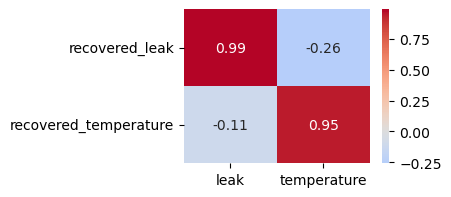

In [21]:
# Solution
plot_param_recovery_confusion_matrix(param_recov_integration)

### Parameter recovery for Model 2 (Extremum detection)

📝Perform parameter recovery for the `ExtremumDetectionModel` with 30 samplings.
> Note: you might get a warning when you run the code. You can ignore it.

In [22]:
# Solution
param_recov_extremum = perform_parameter_recovery(task, ExtremumDetectionModel, 30)
param_recov_extremum.head()

  0%|          | 0/30 [00:00<?, ?it/s]/Users/amrictrudel/anaconda3/envs/ccm/lib/python3.11/site-packages/pybads/init_functions/init_sobol.py:39: RuntimeWarning: invalid value encountered in cast
  str_seed = u0[0 : np.minimum(11, len(u0))].astype(np.uint64)
100%|██████████| 30/30 [00:04<00:00,  6.24it/s]


,epsilon,recovered_epsilon
0,0.833561,0.824944
1,0.174615,0.229177
2,0.809549,0.773828
3,0.467322,0.459949
4,0.106926,0.115001


There is only one parameter in the `ExtremumDetectionModel`, so it doesn't really make sens to plot a confusion matrix.
How else could you visualize the results?

📝Make a graphical representation of the parameter recovery results of the `ExtremumDetectionModel` (model 2).

[]

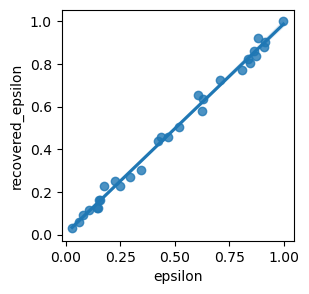

In [23]:
# Solution
plt.figure(figsize=(3, 3))
sns.regplot(param_recov_extremum, x='epsilon', y='recovered_epsilon')
plt.plot()

## Model Recovery


### Akaike Information Criterion
Rememeber, when we perform parameter reccovery, we have to compare the fitness of different models on the same behavioral data. We saw many ways of doing this, but in this TD we will use the **Akaike Information Criterion**.

As a reminder, the formula is the following

$$
\text{AIC} = -2 \cdot \log L + 2k
$$
Where:
- $L$ is the likelihood of the behavior given the fitted model
- $k$ is the number of parameters in the model

In [24]:
# Solution
def akaike_information_criterion(model, task, choices) -> float:
    k = len(model.parameters)
    ll = model.log_likelihood(task, choices)
    aic = -2 * ll + 2 * k
    return aic

📝Complete the `perform_model_recovery` function to perform model recovery for a task and a list of models.
>Notes:
> - The way we sample the parameters has changed since last TDs. You should use the `.parameters` attribute of the model class, like we did in the `perform_parameter_recovery` function.
> - We will only use the Akaike Information Criterion (AIC) to select the winning model. So we will not bother comparing different criteria.

In [25]:
# Solution
def perform_model_recovery(task, model_classes, n_rounds):
    # Instantiate the results as a zero matrix with the model names as row and column labels
    model_names = [model_class.__name__ for model_class in model_classes]
    results = pd.DataFrame(data=0, columns=model_names, index=model_names)
    
    for _ in trange(n_rounds):
        
        for simul_idx, simul_model_class in enumerate(model_classes):
            ########################################################
            ### Simulate the task with the model
            #####
            # Sample parameters for your simulating model using their distributions
            # defined in the .parameters attribute of the model class
            simul_parameters = {
                parameter.name: parameter.distribution.rvs()
                for parameter in simul_model_class.parameters
            }
            simulating_model = simul_model_class(**simul_parameters)
            simulated_choices = simulating_model.simulate(task)

            #########################################################
            ### Fit all candidate models to the simulated data
            ####

            # Loop through all candidate models, fit them and get the AIC for each of them
            aics = []
            for candidate_model_class in model_classes:
                fitted_candidate_model = candidate_model_class.fit(task, simulated_choices, verbose=False)
                aic = akaike_information_criterion(fitted_candidate_model, task, simulated_choices)
                aics.append(aic)

            #######################################################
            ### Select the winning model
            ####

            # Retrieve the index of the model with the best AIC
            select_idx = np.argmin(aics)
            results.iloc[simul_idx, select_idx]  += 1

    return results

📝Run your `perform_model_recovery` function on the task, the two model classes, and 30 rounds (or less if your computer is a bit slow...)

In [26]:
# Solution
model_classes = [IntegrationModel, ExtremumDetectionModel]
model_recovery_results = perform_model_recovery(task, model_classes, n_rounds=30)

  0%|          | 0/30 [00:00<?, ?it/s]/Users/amrictrudel/anaconda3/envs/ccm/lib/python3.11/site-packages/pybads/init_functions/init_sobol.py:39: RuntimeWarning: invalid value encountered in cast
  str_seed = u0[0 : np.minimum(11, len(u0))].astype(np.uint64)
100%|██████████| 30/30 [00:35<00:00,  1.19s/it]


📝 Complete the `plot_model_recovery_inversion_matrix` function that plots the inversion matrix of the model recovery results.
> Note: Although in TD 7, we first computed the confusion matrix, it is not a necessary step. You can directly compute the inversion matrix by performing the appropriate normalization on the model recovery results.

In [27]:
# Solution
def plot_model_recovery_inversion_matrix(model_recovery_results: pd.DataFrame):
    # Compute the inversion matrix (com
    inversion_matrix = model_recovery_results.div(model_recovery_results.sum(axis=0), axis=1)
    # Make a heatmap with appropriate title and axis labels
    plt.figure(figsize=(3, 3))
    sns.heatmap(inversion_matrix, annot=True, fmt='.2f')
    plt.title(f"P(simulated | winning)")
    plt.xlabel("Winning model", fontsize=12)
    plt.ylabel("Simulated model", fontsize=12)

    plt.show()

📝Use your function to pot the inversion matrix of the model recovery results.

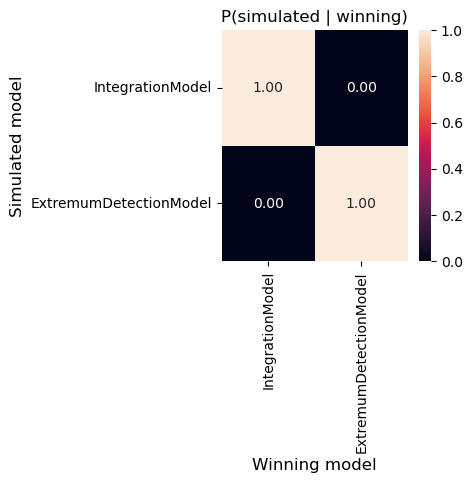

In [28]:
plot_model_recovery_inversion_matrix(model_recovery_results)

## Subject Data
Now we will use data from simulated subjects and try to see what model best explains their behavior.

### Load and inspect the data
The data is given in a DataFrame. The index of each rows indicates a string ID of the participant. Then each column represents the decision taken by the participant at the end of every block.

There are **9 participants**, who completed **200 blocks**.

In [29]:
data = pd.read_csv('data.csv', index_col=0)
data

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
subject,,,,,,,,,,,,,,,,,,,,,
S01,0,1,0,0,0,1,0,0,0,1,...,0,1,0,0,0,1,1,1,0,0
S02,0,1,0,0,0,1,0,0,0,1,...,0,0,1,0,0,1,1,1,0,0
S03,0,0,0,1,1,0,0,0,1,1,...,0,0,1,0,1,1,1,1,0,0
S04,1,1,0,0,1,1,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1
S05,0,1,0,0,1,1,1,1,0,1,...,0,0,1,0,0,1,0,1,1,0
S06,1,1,0,0,1,1,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
S07,1,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,1,1,0,1
S08,0,1,0,0,1,1,0,0,0,0,...,0,1,0,0,0,1,1,1,0,0
S09,0,0,0,0,0,1,0,1,0,1,...,0,1,1,1,0,0,1,0,0,0


## Fit the models to each subject

📝Define again the model classes that we want to fit to the data (here, it is the same two models as before).

In [30]:
# Solution
model_classes = [IntegrationModel, ExtremumDetectionModel]

📝Complete the `fit_all_models_to_each_subject` function to fit all models to each subject's data.

In [31]:
# Solution
def fit_all_models_to_each_subject(model_classes, task, data: pd.DataFrame):
    results_aic = pd.DataFrame(index=data.index, columns=[mc.__name__ for mc in model_classes])
    for subject_id, subject_choices in tqdm(data.iterrows()):
        subject_choices = subject_choices.values.reshape(-1, 1)
        for model_class in model_classes:
            # Fit the model to the subject's choices
            fitted_model = model_class.fit(task , subject_choices, verbose=False)

            # Compute the AIC for the fitted model
            aic = akaike_information_criterion(fitted_model, task, subject_choices)
            results_aic.loc[subject_id, model_class.__name__] = aic
    return results_aic

📝With the `fit_all_models_to_each_subject` function, fit all models to each subject's data and collect the AIC scores in a dataframe.

Examine the `aic_per_subject_and_model` dataframe to make sure it seems reasonable.

In [32]:
# Solution
aic_per_subject_and_model = fit_all_models_to_each_subject(model_classes, task, data)
aic_per_subject_and_model

0it [00:00, ?it/s]/Users/amrictrudel/anaconda3/envs/ccm/lib/python3.11/site-packages/pybads/init_functions/init_sobol.py:39: RuntimeWarning: invalid value encountered in cast
  str_seed = u0[0 : np.minimum(11, len(u0))].astype(np.uint64)
9it [00:05,  1.75it/s]


,IntegrationModel,ExtremumDetectionModel
subject,,
S01,67.209322,177.867953
S02,8.709243,160.312879
S03,289.934034,255.671456
S04,164.22109,258.414191
S05,196.534158,118.325762
S06,69.370514,244.62724
S07,152.46965,222.431973
S08,44.026975,207.582672
S09,316.73028,279.178873


## Model Selection

### (Approximate) Log Model Evidence
When we do model selection, it is common to use the log model evidence of a model as a measure of how well it explains the data.
The log model evidence of a model $M$ on behavioral data $D$ is defined as the log probability of  $\log p(M|D)$.

We have already computed the *Akaike Information Criterion* (AIC) for each model and each subject, but this criterion does not have the same interpretation as the log model evidence. We need to rescale it to make it look like a log probability.

We will approximate the log model evidence using the AIC as follows:
$$
\log p(M|D) \approx -\frac{1}{2} \text{AIC}(M|D)
$$

📝Compute the `lme_per_subject` dataframe, which is the log model evidence for each model and each subject.

In [33]:
# Solution
lme_per_subject = aic_per_subject_and_model / -2
lme_per_subject

,IntegrationModel,ExtremumDetectionModel
subject,,
S01,-33.604661,-88.933977
S02,-4.354622,-80.156439
S03,-144.967017,-127.835728
S04,-82.110545,-129.207096
S05,-98.267079,-59.162881
S06,-34.685257,-122.31362
S07,-76.234825,-111.215986
S08,-22.013487,-103.791336
S09,-158.36514,-139.589436


### Fixed effect model selection
Do you remember the difference between fixed effects and random effects model selection?

- **Fixed effect**: We assume that the model is the same for all subjects. We can use the log model evidence of each model to compare them.
- **Random effect**: We assume that the model is different for each subject. We can use the log model evidence of each model to compute the probability of each model given the data.

📝 Compute the log model evidence for each model by summing the log model evidences over subjects.

`lme_fixed_effect` should be a Pandas Series that contains the log model evidence for each mode

In [34]:
# Solution
lme_fixed_effect = lme_per_subject.sum(axis=0)
lme_fixed_effect

IntegrationModel         -654.602633
ExtremumDetectionModel     -962.2065
dtype: object

📝 Show the comparison of the log model evidences for each model using a bar plot.


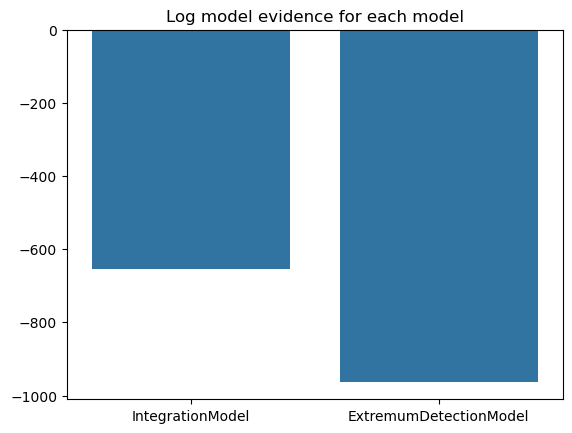

In [35]:
# Solution
sns.barplot(lme_fixed_effect)
plt.title('Log model evidence for each model')
plt.show()

💭 What model seems to best explain the behavior of the entire sample of subjects?

### Random effect model selection
In random effect model selection, we assume that the model is different for each subject, and the goal is to find the model that best explains the data for each subject.
To achieve this, for each subject, we can subtract the log model evidence of both models and visualize the difference.

📝Compute the difference between the log model evidenc of the `IntegrationModel` and the `ExtremumDetectionModel` for each subject.
The result should be stored as `lme_diff_per_subject`, a Pandas Series with the subject ids as index and the differences as values.

In [36]:
# Solution
lme_diff_per_subject = (lme_per_subject['IntegrationModel'] - lme_per_subject['ExtremumDetectionModel']).astype(float)
lme_diff_per_subject

subject
S01    55.329316
S02    75.801818
S03   -17.131289
S04    47.096551
S05   -39.104198
S06    87.628363
S07    34.981161
S08    81.777849
S09   -18.775703
dtype: float64

📝Visualize the differences in a horizontal bar plot. The y axis should be the subject ids and the x axis should be the difference between the log model evidences.

<Axes: ylabel='subject'>

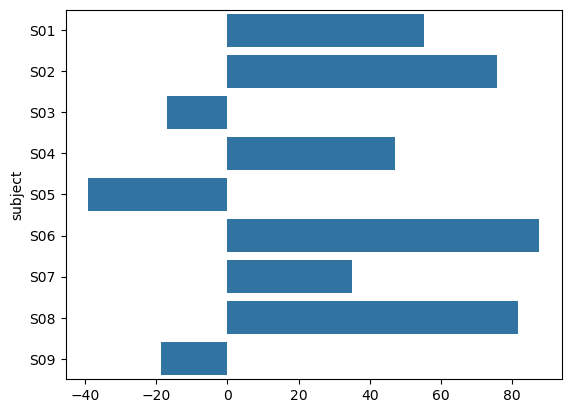

In [37]:
sns.barplot(lme_diff_per_subject, orient='h')

💭 Which subjects seem to operate according to the **integration model**? And **extremum detection model**?

### 💪 Cognitive Phenotyping (optional)
If you want to go futher, you could determine the **cognitive phenotype** of all the subject to whom the **integration model** is a best fit. Give the estimated parameter values for each of them.

In [38]:
# I'll let you do it 😄

You can do the same with the subjects that are best fit by the **extremum detection model**.

In [39]:
# This one too 😄